# Robust allocation under estimation error

[Research note](README.md) · [Project overview](../../README.md)

An optimizer acts on estimated inputs. This experiment asks how much the portfolio changes when equally plausible training samples change, and what its risk becomes when correlations shift. The five candidate rules, 35% caps, two stress transformations, sample sizes and random seeds are fixed below. All returns are **constructed**, with no empirical performance claim. This is an original finite-scenario illustration; it is not a replication of a paper's results.

## Design before comparison

Six assets share market and group factors. We generate 126 training observations and an independent 252-observation test sample with stronger common-factor exposure. Train and test have zero expected return: this is a risk-estimation experiment, not an alpha search. The true test covariance is available to the evaluator because we constructed the world. It never enters portfolio fitting.

Compare equal weight, sample minimum variance (GMV), identity-shrinkage GMV with a 35% cap, sample HRP, and capped minimum worst-scenario variance. The latter uses the *training* shrunk covariance and two fixed transformations: higher common correlation at unchanged marginal volatility, and 50% higher volatility in the first three assets. These are modeling assumptions, not statistical confidence bounds.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / "research").is_dir():
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from research.robust_allocation import allocation_candidates, covariance_scenarios
from sklearn.covariance import LedoitWolf

assets = ["Equity A", "Equity B", "Credit", "Duration A", "Duration B", "Diversifier"]
loadings = np.array([[.009,.006,0], [.008,.006,0], [.006,.004,0],
                     [.001,0,.005], [.002,0,.007], [.001,.002,.002]])
idio = np.diag(np.array([.006,.008,.005,.004,.006,.005])**2)
train_cov = loadings @ loadings.T + idio
shifted = loadings.copy()
shifted[:, 0] += .006
true_test_cov = shifted @ shifted.T + idio
train_rng = np.random.default_rng(20260919)
test_rng = np.random.default_rng(20260920)
training = train_rng.multivariate_normal(np.zeros(6), train_cov, size=126)
testing = test_rng.multivariate_normal(np.zeros(6), true_test_cov, size=252)
weights = allocation_candidates(training, cap=.35)
weight_table = pd.DataFrame(weights, index=assets).T
np.testing.assert_allclose(weight_table.sum(axis=1), 1, atol=1e-8)
assert weight_table.to_numpy().min() >= -1e-10
display(weight_table.round(4))

,Equity A,Equity B,Credit,Duration A,Duration B,Diversifier
Equal weight,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667
Sample GMV,0.0000,0.0204,0.1393,0.3537,0.0000,0.4866
Shrunk capped GMV,0.0000,0.0460,0.1879,0.3500,0.0661,0.3500
HRP,0.0438,0.1012,0.0905,0.2126,0.1068,0.4452
Scenario capped GMV,0.0000,0.0000,0.2410,0.3500,0.0590,0.3500


## Fit only on the training sample

For each candidate report nominal training volatility, the worst risk across the *same* declared training scenarios, realized test volatility, and evaluator-only true test volatility. The common scenario set allows a fair comparison of the objectives. A cap can reduce concentration while increasing variance; shrinkage stabilizes an estimate without guaranteeing a better decision. HRP can still change its clustering when correlations change.

,training_vol,worst_declared_vol,realized_test_vol,true_test_vol,largest_weight,effective_assets
rule,,,,,,
Equal weight,0.1057,0.1410,0.1886,0.1812,0.1667,6.0000
Sample GMV,0.0801,0.0972,0.1509,0.1421,0.4866,2.6198
Shrunk capped GMV,0.0819,0.1024,0.1563,0.1481,0.3500,3.4868
HRP,0.0846,0.1063,0.1614,0.1532,0.4452,3.6349
Scenario capped GMV,0.0820,0.1016,0.1553,0.1471,0.3500,3.2620


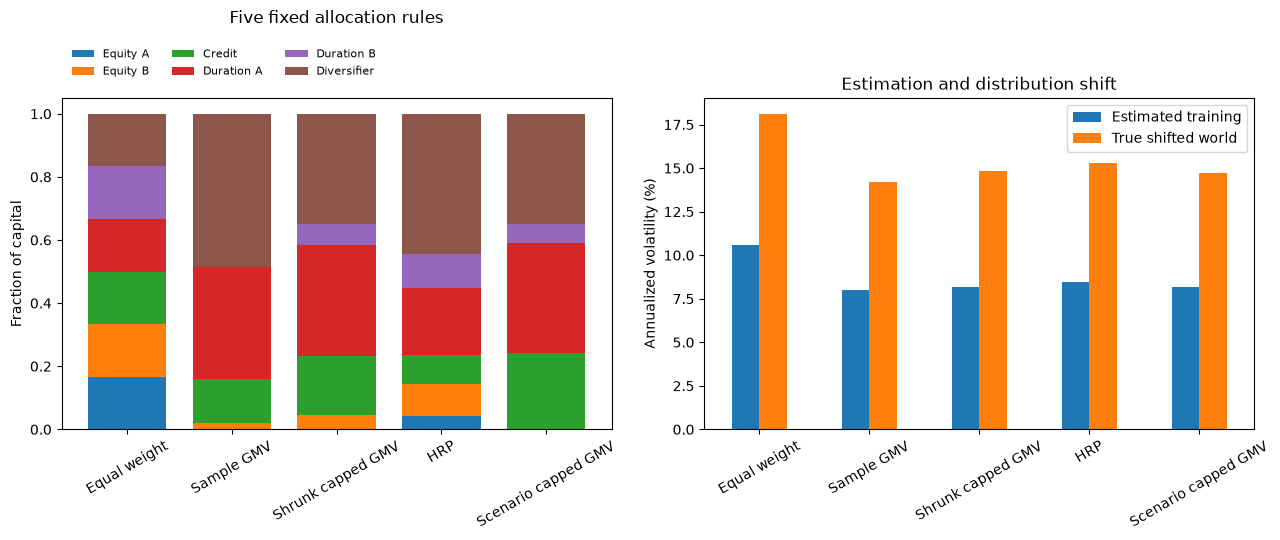

In [2]:
sample_cov = np.cov(training, rowvar=False, ddof=1)
scenarios = covariance_scenarios(LedoitWolf().fit(training).covariance_)
rows = []
for name, w in weights.items():
    rows.append({"rule": name,
        "training_vol": np.sqrt(252 * w @ sample_cov @ w),
        "worst_declared_vol": np.sqrt(252 * max(w @ c @ w for c in scenarios)),
        "realized_test_vol": np.std(testing @ w, ddof=1) * np.sqrt(252),
        "true_test_vol": np.sqrt(252 * w @ true_test_cov @ w),
        "largest_weight": w.max(), "effective_assets": 1 / (w @ w)})
risk = pd.DataFrame(rows).set_index("rule")
display(risk.round(4))
# Same feasible set: scenario objective cannot exceed its value at capped GMV.
assert risk.loc["Scenario capped GMV", "worst_declared_vol"] <= risk.loc["Shrunk capped GMV", "worst_declared_vol"] + 1e-7
# Test data may change evaluation, but cannot change frozen training-only weights.
changed_test = testing + .2
for name, w in allocation_candidates(training).items():
    np.testing.assert_array_equal(w, weights[name])
assert not np.allclose(changed_test @ weights["HRP"], testing @ weights["HRP"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
weight_table.plot.bar(stacked=True, ax=axes[0], width=.75)
axes[0].set(ylabel="Fraction of capital", xlabel="", title="Five fixed allocation rules")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=8, ncol=3, loc="upper left", bbox_to_anchor=(0, 1.18), frameon=False)
axes[0].set_title("Five fixed allocation rules", pad=54)
(risk[["training_vol", "true_test_vol"]] * 100).rename(columns={"training_vol":"Estimated training", "true_test_vol":"True shifted world"}).plot.bar(ax=axes[1])
axes[1].set(ylabel="Annualized volatility (%)", xlabel="", title="Estimation and distribution shift")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

## Refit under input perturbations

Resample complete daily asset vectors, refit every estimator and optimizer, and compare weights with the original training fit. These IID draws suit this constructed IID world. For market returns with serial dependence, use an appropriate joint block design and keep all asset columns aligned.

Report the distribution of **half-L1 target-weight distance**, $\tfrac12\sum_i |w_i^{(b)}-w_i|$, and the evaluator-only true test volatility for 120 bootstrap fits. This measures local sensitivity conditional on one sample; it is neither actual trading turnover nor a confidence interval for future returns. The bootstrap is never used to choose a winner or change the fixed settings.

,median_distance,p90_distance,median_true_vol,p90_true_vol
rule,,,,
Equal weight,0.0000,0.0000,0.1812,0.1812
Sample GMV,0.0943,0.1778,0.1435,0.1470
Shrunk capped GMV,0.0515,0.0862,0.1485,0.1515
HRP,0.0789,0.1630,0.1531,0.1562
Scenario capped GMV,0.0469,0.1007,0.1475,0.1499


/tmp/ipykernel_225928/1185689532.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([perturbations.query('rule == @name').target_distance.to_numpy() for name in weights],


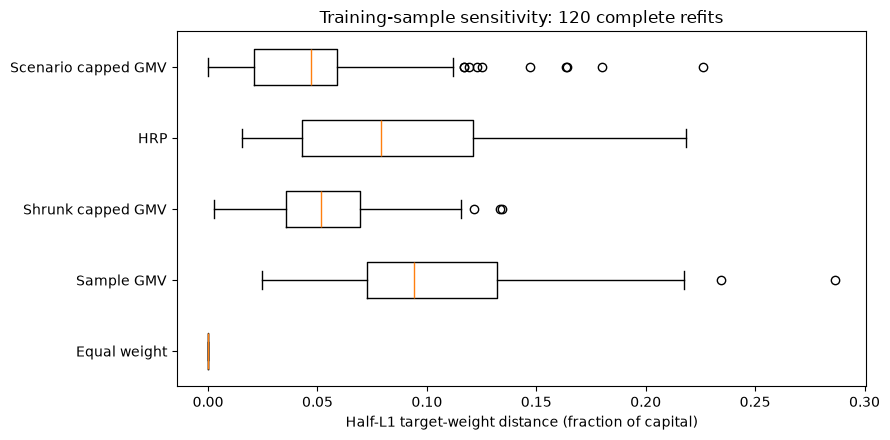

In [3]:
bootstrap_rng = np.random.default_rng(20260921)
perturbations = []
for draw in range(120):
    idx = bootstrap_rng.integers(0, len(training), size=len(training))
    fitted = allocation_candidates(training[idx], cap=.35)
    for name, w in fitted.items():
        perturbations.append({"draw":draw, "rule":name,
            "target_distance":.5 * np.abs(w - weights[name]).sum(),
            "true_test_vol":np.sqrt(252 * w @ true_test_cov @ w)})
perturbations = pd.DataFrame(perturbations)
summary = perturbations.groupby("rule").agg(
    median_distance=("target_distance", "median"),
    p90_distance=("target_distance", lambda x: x.quantile(.9)),
    median_true_vol=("true_test_vol", "median"),
    p90_true_vol=("true_test_vol", lambda x: x.quantile(.9)))
display(summary.reindex(weights).round(4))
assert (perturbations.query('rule == "Equal weight"').target_distance == 0).all()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot([perturbations.query('rule == @name').target_distance.to_numpy() for name in weights],
           tick_labels=list(weights), vert=False, showfliers=True)
ax.set(xlabel="Half-L1 target-weight distance (fraction of capital)",
       title="Training-sample sensitivity: 120 complete refits")
fig.tight_layout()
plt.show()

## What this contributes to a strategy

In this fixed draw, the capped shrunk allocation has smaller typical target changes than sample GMV, while carrying more risk in the evaluator's shifted world. HRP also moves under sample perturbations. The objectives have real tradeoffs; stability does not identify a universal winner.

The risk table separates estimated safety from risk under a specified distribution change. The refit table identifies unstable *decisions*, not just unstable covariance entries. Equal weight has zero estimation-driven weight variation but can still carry substantial economic risk. Scenario allocation trades nominal fit against the scenarios we chose; it cannot protect against omitted states.

A deployable allocation study would freeze the universe and candidate library, use rolling training-only fits, include observed cash returns and self-financing turnover costs, and retain every attempted specification. [Purged validation](../10-purged-validation/README.md) addresses overlapping forecast labels when a predictive model is added; [selection diagnostics](../11-backtest-selection/README.md) address choosing among many backtests. These solve different problems from covariance shrinkage. The existing [ETF study](../../study.ipynb) supplies a retrospective accounting case, not a new untouched test for these five candidates.

The example fixes one cap and one stress set. Varying either after seeing this output would create additional research trials that must be recorded. No candidate is promoted on this sample alone.

## References and scope

- [López de Prado (2016), HRP](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2708678): hierarchical portfolio construction; this notebook does not reproduce the paper's reported performance.
- [Ledoit–Wolf implementation and original 2004 reference](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html): analytical identity-target covariance shrinkage. This is not the constant-correlation target in *Honey, I Shrunk the Sample Covariance Matrix*.
- [SciPy constrained optimization](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html): numerical solver. The finite-scenario minimax objective is defined in the research note and implemented independently here.

The accompanying tests compare diagonal GMV with its analytic solution and two-scenario minimax with an exhaustive one-dimensional grid.